# 🎰 MEGA-SENA: RESUMO FINAL E RECOMENDAÇÕES

## Dashboard Completo com:
- 🔥 Top 10 números mais frequentes
- ❄️ Top 10 números menos frequentes
- 📊 Comparativo de estratégias
- 🎯 Recomendação de números para apostar (6 a 10 números)

## ⚠️ Importante:
As janelas ótimas abaixo foram obtidas executando o notebook `analise_comparativa_metodos_v3.ipynb`.
Execute-o primeiro para obter os valores atualizados do dicionário `JANELAS_OTIMAS`.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
from scipy.stats import hypergeom
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'
np.random.seed(42)

print("✅ Bibliotecas carregadas!")

✅ Bibliotecas carregadas!


In [48]:
# Carregar dados
df = pd.read_excel('Mega-Sena.xlsx')
ball_columns = ['Bola1', 'Bola2', 'Bola3', 'Bola4', 'Bola5', 'Bola6']
sorteios = np.sort(df[ball_columns].dropna().astype(int).values, axis=1)

TOTAL_CONCURSOS = len(sorteios)
print(f"✅ {TOTAL_CONCURSOS:,} concursos carregados!")

✅ 2,949 concursos carregados!


In [49]:
# ============================================================================
# CONFIGURAÇÕES E FUNÇÕES
# ============================================================================

def calc_freq(sorteios_arr):
    counter = Counter(sorteios_arr.flatten())
    return np.array([counter.get(i, 0) for i in range(1, 61)])

def get_topN(freq, n):
    return sorted(np.argsort(freq)[-n:] + 1)

def get_bottomN(freq, n):
    return sorted(np.argsort(freq)[:n] + 1)

def contar_acertos(aposta, sorteio):
    return len(set(aposta) & set(sorteio))

# ============================================================================
# JANELAS ÓTIMAS POR QUANTIDADE DE NÚMEROS
# ============================================================================
# Estes valores foram obtidos executando analise_comparativa_metodos_v3.ipynb
# Eles representam o tamanho de janela que maximiza a média de acertos
# para a estratégia Top N (números mais frequentes)
#
# ATUALIZE ESTES VALORES após executar a análise V3!
# O notebook V3 mostra: JANELAS_OTIMAS = {resultado_calculado}
# ============================================================================

JANELAS_OTIMAS = {6: 1000, 7: 1200, 8: 800, 9: 850, 10: 850}

# Janela para estatísticas gerais (usar a do Top 6)
JANELA_ESTATISTICAS = JANELAS_OTIMAS[6]

# Janelas para análise comparativa
JANELAS = [50, 100, 200, 300, 500, 800, 850, 1000, 1200]

print("✅ Configurações definidas!")
print(f"\n📊 Janelas ótimas por quantidade de números (Top N):")
print("   (Valores obtidos da análise V3)")
for n, j in JANELAS_OTIMAS.items():
    print(f"   {n} números → janela de {j} jogos")

✅ Configurações definidas!

📊 Janelas ótimas por quantidade de números (Top N):
   (Valores obtidos da análise V3)
   6 números → janela de 1000 jogos
   7 números → janela de 1200 jogos
   8 números → janela de 800 jogos
   9 números → janela de 850 jogos
   10 números → janela de 850 jogos


In [50]:
# ============================================================================
# CÁLCULO DOS TOP NÚMEROS PARA CADA QUANTIDADE
# ============================================================================

# Calcular frequências para cada janela necessária
janelas_unicas = set(JANELAS_OTIMAS.values()) | {JANELA_ESTATISTICAS}
freq_por_janela = {}

for j in janelas_unicas:
    if j <= len(sorteios):
        freq_por_janela[j] = calc_freq(sorteios[-j:])

# Calcular os top números para cada quantidade
top_numeros = {}
for n_nums, janela in JANELAS_OTIMAS.items():
    freq = freq_por_janela[janela]
    top_numeros[n_nums] = get_topN(freq, n_nums)

print("="*70)
print("🎯 NÚMEROS RECOMENDADOS POR QUANTIDADE (Top N)")
print("="*70)
for n_nums in [6, 7, 8, 9, 10]:
    nums = top_numeros[n_nums]
    janela = JANELAS_OTIMAS[n_nums]
    print(f"\n   {n_nums} números (janela ótima: {janela}): {nums}")

🎯 NÚMEROS RECOMENDADOS POR QUANTIDADE (Top N)

   6 números (janela ótima: 1000): [10, 11, 34, 37, 38, 46]

   7 números (janela ótima: 1200): [10, 11, 25, 34, 35, 37, 38]

   8 números (janela ótima: 800): [10, 11, 25, 34, 37, 38, 46, 53]

   9 números (janela ótima: 850): [10, 11, 25, 34, 35, 37, 38, 46, 53]

   10 números (janela ótima: 850): [10, 11, 25, 34, 35, 37, 38, 44, 46, 53]


In [51]:
# ============================================================================
# ANÁLISE DE PERFORMANCE
# ============================================================================

# Frequência para estatísticas
freq_estatisticas = freq_por_janela[JANELA_ESTATISTICAS]
freq_total = calc_freq(sorteios)

# Análise de performance por estratégia
print("⏳ Analisando performance das estratégias...")

janelas_analise = [50, 100, 200, 500, 800, 1000, 1200]
resultados = {j: {'top': [], 'bottom': [], 'mista': [], 'aleatorio': []} for j in janelas_analise}

for j in janelas_analise:
    for i in range(j, len(sorteios)):
        freq = calc_freq(sorteios[i-j:i])
        sorteio = sorteios[i]
        
        top6 = get_topN(freq, 6)
        bottom6 = get_bottomN(freq, 6)
        mista = sorted(list(get_bottomN(freq, 3)) + list(get_topN(freq, 3)))
        alea = sorted(np.random.choice(range(1, 61), 6, replace=False))
        
        resultados[j]['top'].append(contar_acertos(top6, sorteio))
        resultados[j]['bottom'].append(contar_acertos(bottom6, sorteio))
        resultados[j]['mista'].append(contar_acertos(mista, sorteio))
        resultados[j]['aleatorio'].append(contar_acertos(alea, sorteio))

medias = {j: {est: np.mean(resultados[j][est]) for est in ['top', 'bottom', 'mista', 'aleatorio']} for j in janelas_analise}
VALOR_TEORICO = hypergeom.mean(60, 6, 6)

print("✅ Análise concluída!")

⏳ Analisando performance das estratégias...
✅ Análise concluída!


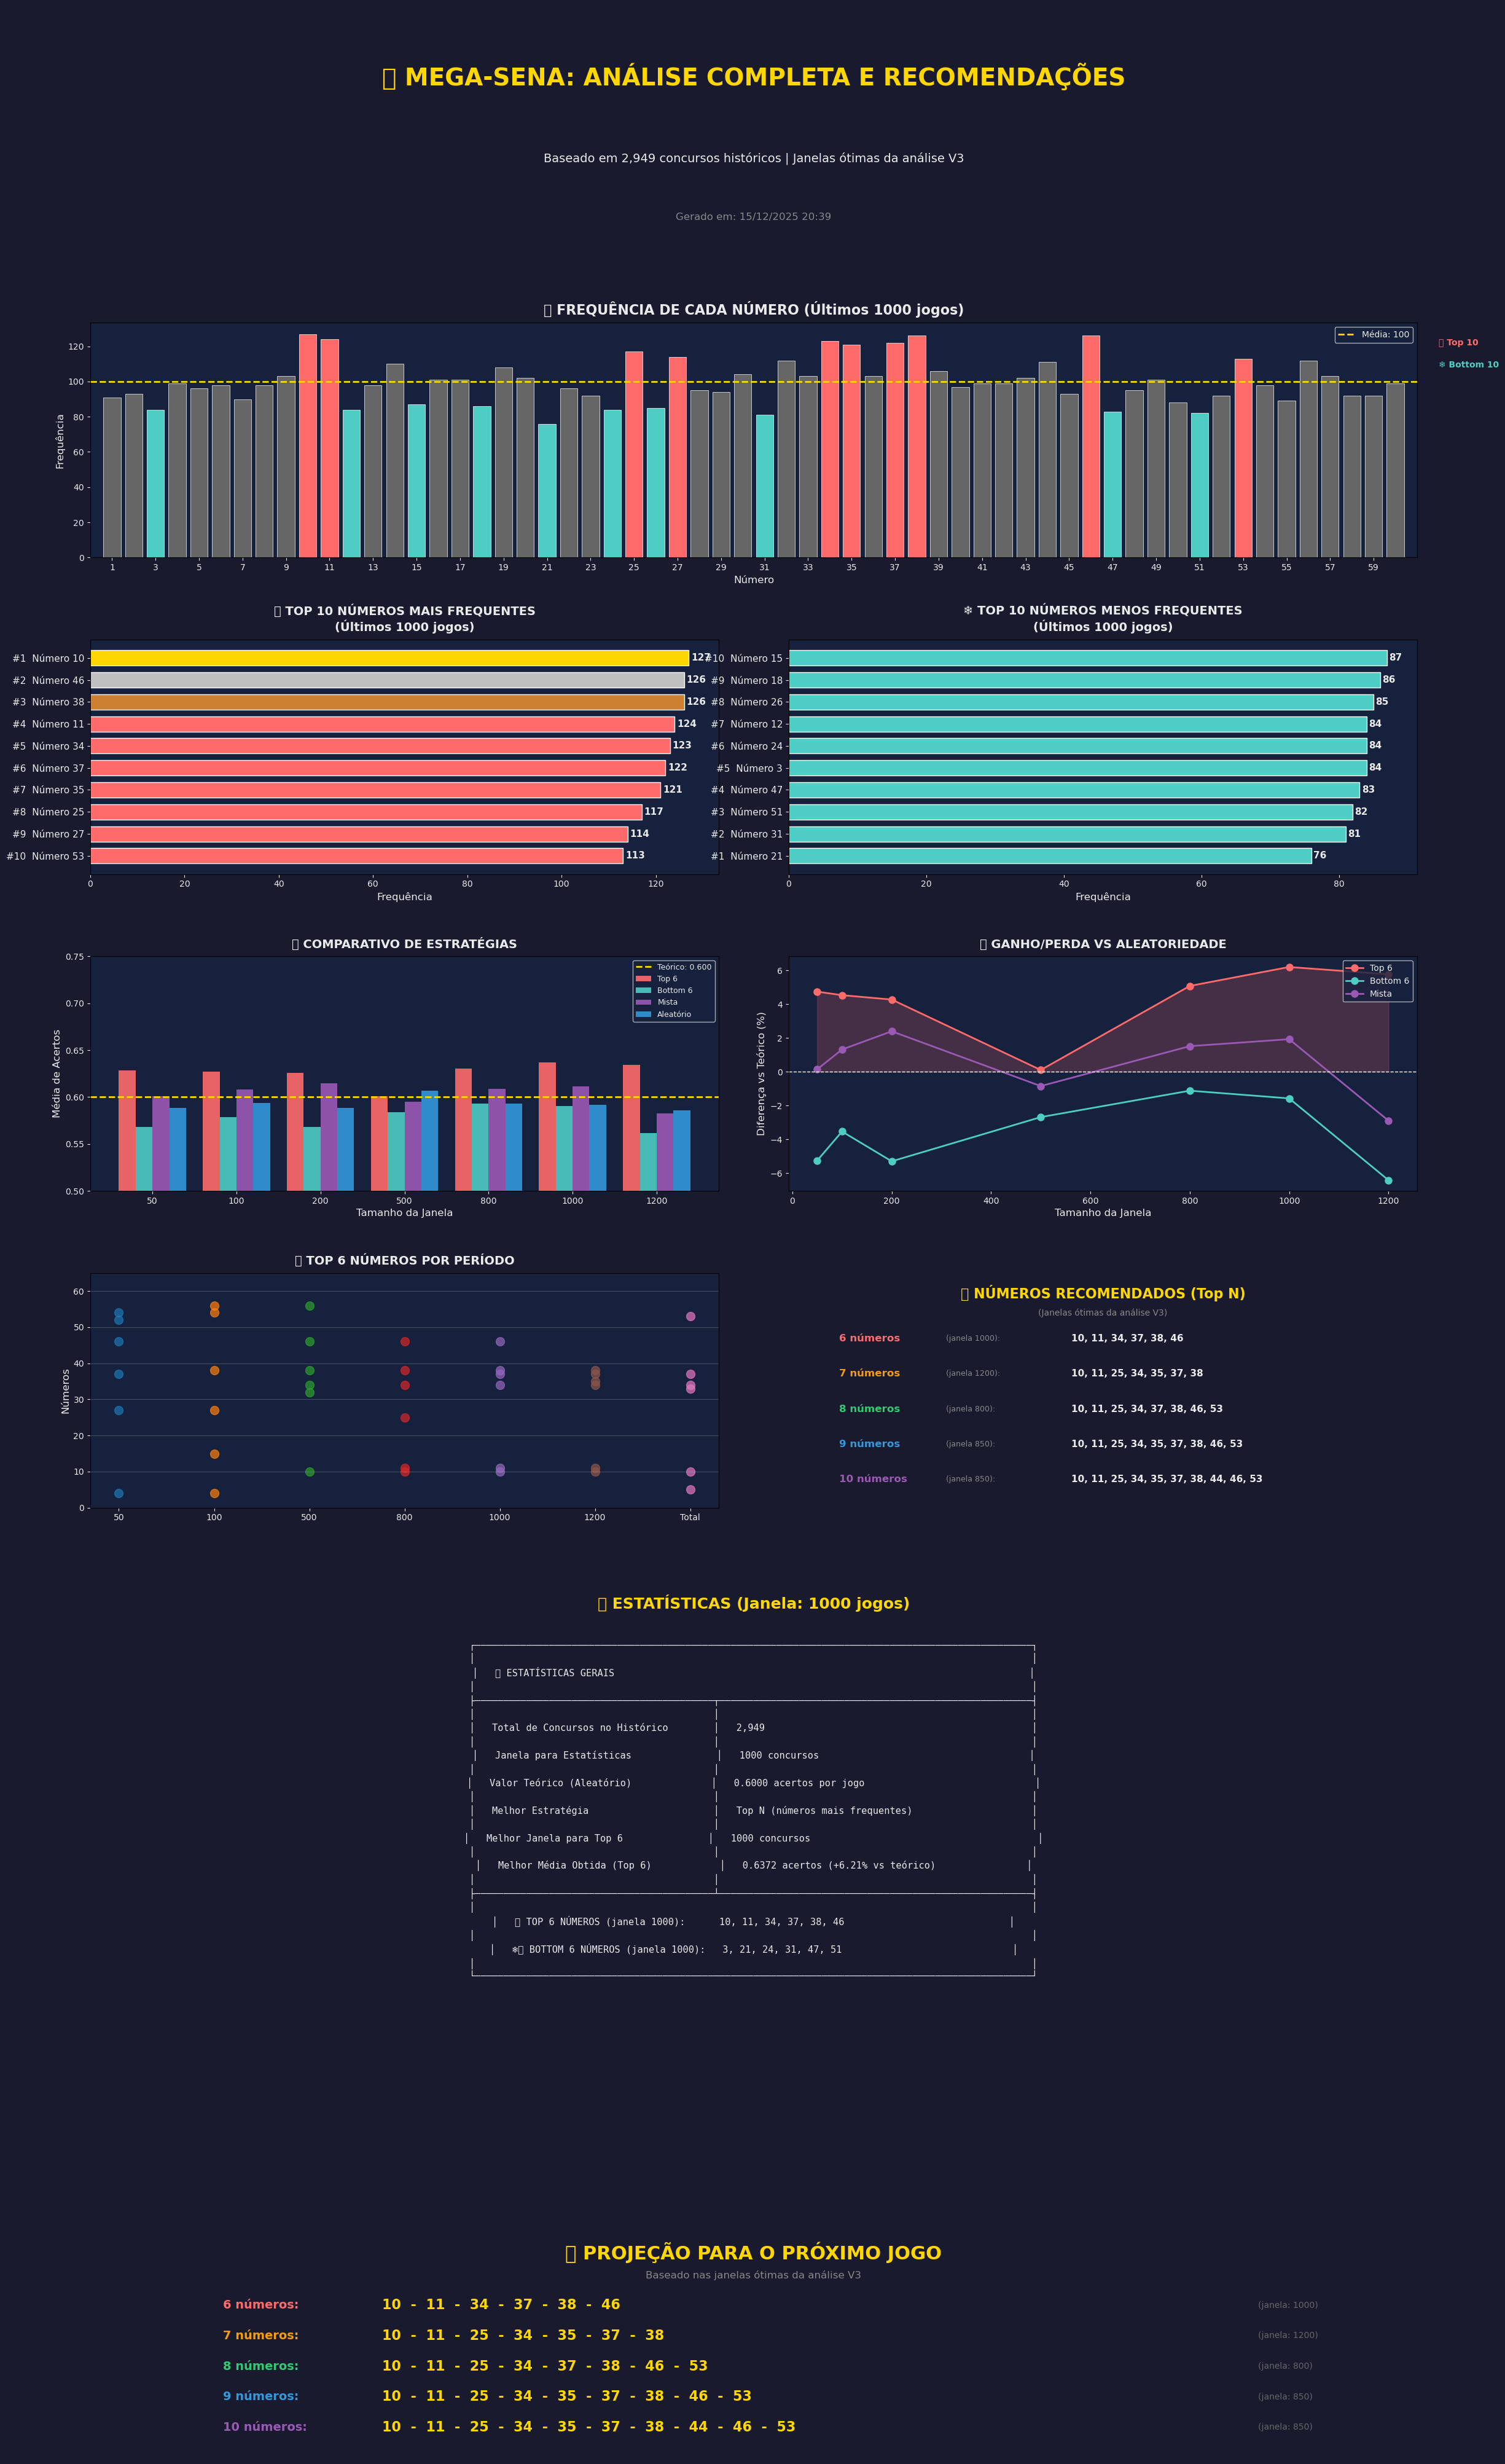


✅ Dashboard salvo como 'mega_sena_dashboard_final.png'


In [52]:
# ============================================================================
# DASHBOARD PRINCIPAL
# ============================================================================

# Cores
COR_TOP = '#FF6B6B'
COR_BOTTOM = '#4ECDC4'
COR_MISTA = '#9B59B6'
COR_ALEA = '#3498DB'
COR_BG = '#1a1a2e'
COR_CARD = '#16213e'
COR_TEXT = '#eaeaea'
COR_GOLD = '#FFD700'
COR_SILVER = '#C0C0C0'
COR_BRONZE = '#CD7F32'

fig = plt.figure(figsize=(24, 42), facecolor=COR_BG)
gs = GridSpec(8, 4, figure=fig, hspace=0.35, wspace=0.25, 
              left=0.05, right=0.95, top=0.97, bottom=0.02)

# ============================================================================
# TÍTULO PRINCIPAL
# ============================================================================
ax_title = fig.add_subplot(gs[0, :])
ax_title.set_facecolor(COR_BG)
ax_title.axis('off')

ax_title.text(0.5, 0.7, '🎰 MEGA-SENA: ANÁLISE COMPLETA E RECOMENDAÇÕES', 
              fontsize=28, fontweight='bold', color=COR_GOLD, ha='center', va='center')
ax_title.text(0.5, 0.35, f'Baseado em {TOTAL_CONCURSOS:,} concursos históricos | Janelas ótimas da análise V3', 
              fontsize=14, color=COR_TEXT, ha='center', va='center')
ax_title.text(0.5, 0.1, f'Gerado em: {datetime.now().strftime("%d/%m/%Y %H:%M")}', 
              fontsize=12, color='#888', ha='center', va='center')

# ============================================================================
# FREQUÊNCIA DOS 60 NÚMEROS
# ============================================================================
ax1 = fig.add_subplot(gs[1, :])
ax1.set_facecolor(COR_CARD)

numeros = np.arange(1, 61)
cores_barras = []
sorted_idx = np.argsort(freq_estatisticas)
top10_nums = set(sorted_idx[-10:] + 1)
bottom10_nums = set(sorted_idx[:10] + 1)

for n in numeros:
    if n in top10_nums:
        cores_barras.append(COR_TOP)
    elif n in bottom10_nums:
        cores_barras.append(COR_BOTTOM)
    else:
        cores_barras.append('#666')

bars = ax1.bar(numeros, freq_estatisticas, color=cores_barras, edgecolor='white', linewidth=0.5)
ax1.axhline(y=np.mean(freq_estatisticas), color=COR_GOLD, linestyle='--', linewidth=2, 
            label=f'Média: {np.mean(freq_estatisticas):.0f}')

ax1.set_xlabel('Número', fontsize=12, color=COR_TEXT)
ax1.set_ylabel('Frequência', fontsize=12, color=COR_TEXT)
ax1.set_title(f'📊 FREQUÊNCIA DE CADA NÚMERO (Últimos {JANELA_ESTATISTICAS} jogos)', fontsize=16, 
              fontweight='bold', color=COR_TEXT, pad=10)
ax1.set_xticks(range(1, 61, 2))
ax1.tick_params(colors=COR_TEXT)
ax1.legend(loc='upper right', facecolor=COR_CARD, labelcolor=COR_TEXT)
ax1.set_xlim(0, 61)

ax1.text(62, max(freq_estatisticas)*0.95, '🔥 Top 10', color=COR_TOP, fontsize=10, fontweight='bold')
ax1.text(62, max(freq_estatisticas)*0.85, '❄️ Bottom 10', color=COR_BOTTOM, fontsize=10, fontweight='bold')

# ============================================================================
# TOP 10 NÚMEROS
# ============================================================================
ax2 = fig.add_subplot(gs[2, 0:2])
ax2.set_facecolor(COR_CARD)

top10_recente = np.argsort(freq_estatisticas)[-10:][::-1] + 1
top10_freqs = freq_estatisticas[top10_recente - 1]

cores_top = [COR_GOLD if i == 0 else COR_SILVER if i == 1 else COR_BRONZE if i == 2 else COR_TOP for i in range(10)]

bars2 = ax2.barh(range(10), top10_freqs[::-1], color=cores_top[::-1], edgecolor='white', height=0.7)
ax2.set_yticks(range(10))
ax2.set_yticklabels([f'#{10-i}  Número {top10_recente[::-1][i]}' for i in range(10)], fontsize=11, color=COR_TEXT)
ax2.set_xlabel('Frequência', fontsize=12, color=COR_TEXT)
ax2.set_title(f'🔥 TOP 10 NÚMEROS MAIS FREQUENTES\n(Últimos {JANELA_ESTATISTICAS} jogos)', 
              fontsize=14, fontweight='bold', color=COR_TEXT, pad=10)
ax2.tick_params(colors=COR_TEXT)

for bar, freq in zip(bars2, top10_freqs[::-1]):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{int(freq)}', va='center', fontsize=11, color=COR_TEXT, fontweight='bold')

# ============================================================================
# BOTTOM 10 NÚMEROS
# ============================================================================
ax3 = fig.add_subplot(gs[2, 2:4])
ax3.set_facecolor(COR_CARD)

bottom10_recente = np.argsort(freq_estatisticas)[:10] + 1
bottom10_freqs = freq_estatisticas[bottom10_recente - 1]

bars3 = ax3.barh(range(10), bottom10_freqs, color=COR_BOTTOM, edgecolor='white', height=0.7)
ax3.set_yticks(range(10))
ax3.set_yticklabels([f'#{i+1}  Número {bottom10_recente[i]}' for i in range(10)], fontsize=11, color=COR_TEXT)
ax3.set_xlabel('Frequência', fontsize=12, color=COR_TEXT)
ax3.set_title(f'❄️ TOP 10 NÚMEROS MENOS FREQUENTES\n(Últimos {JANELA_ESTATISTICAS} jogos)', 
              fontsize=14, fontweight='bold', color=COR_TEXT, pad=10)
ax3.tick_params(colors=COR_TEXT)

for bar, freq in zip(bars3, bottom10_freqs):
    ax3.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{int(freq)}', va='center', fontsize=11, color=COR_TEXT, fontweight='bold')

# ============================================================================
# COMPARATIVO DE ESTRATÉGIAS
# ============================================================================
ax4 = fig.add_subplot(gs[3, 0:2])
ax4.set_facecolor(COR_CARD)

x = np.arange(len(janelas_analise))
width = 0.2

for i, (est, cor, nome) in enumerate([('top', COR_TOP, 'Top 6'), ('bottom', COR_BOTTOM, 'Bottom 6'), 
                                       ('mista', COR_MISTA, 'Mista'), ('aleatorio', COR_ALEA, 'Aleatório')]):
    vals = [medias[j][est] for j in janelas_analise]
    ax4.bar(x + i*width, vals, width, label=nome, color=cor, alpha=0.9)

ax4.axhline(y=VALOR_TEORICO, color=COR_GOLD, linestyle='--', linewidth=2, label=f'Teórico: {VALOR_TEORICO:.3f}')

ax4.set_xlabel('Tamanho da Janela', fontsize=12, color=COR_TEXT)
ax4.set_ylabel('Média de Acertos', fontsize=12, color=COR_TEXT)
ax4.set_title('📊 COMPARATIVO DE ESTRATÉGIAS', fontsize=14, fontweight='bold', color=COR_TEXT, pad=10)
ax4.set_xticks(x + 1.5*width)
ax4.set_xticklabels([str(j) for j in janelas_analise], color=COR_TEXT)
ax4.tick_params(colors=COR_TEXT)
ax4.legend(loc='upper right', facecolor=COR_CARD, labelcolor=COR_TEXT, fontsize=9)
ax4.set_ylim(0.5, 0.75)

# ============================================================================
# DIFERENÇA % VS TEÓRICO
# ============================================================================
ax5 = fig.add_subplot(gs[3, 2:4])
ax5.set_facecolor(COR_CARD)

for est, cor, nome in [('top', COR_TOP, 'Top 6'), ('bottom', COR_BOTTOM, 'Bottom 6'), ('mista', COR_MISTA, 'Mista')]:
    diffs = [((medias[j][est] - VALOR_TEORICO) / VALOR_TEORICO) * 100 for j in janelas_analise]
    ax5.plot(janelas_analise, diffs, 'o-', color=cor, label=nome, linewidth=2, markersize=8)

ax5.axhline(y=0, color='white', linestyle='--', linewidth=1)
ax5.fill_between(janelas_analise, 0, [((medias[j]['top'] - VALOR_TEORICO) / VALOR_TEORICO) * 100 for j in janelas_analise], 
                  alpha=0.2, color=COR_TOP)

ax5.set_xlabel('Tamanho da Janela', fontsize=12, color=COR_TEXT)
ax5.set_ylabel('Diferença vs Teórico (%)', fontsize=12, color=COR_TEXT)
ax5.set_title('📈 GANHO/PERDA VS ALEATORIEDADE', fontsize=14, fontweight='bold', color=COR_TEXT, pad=10)
ax5.tick_params(colors=COR_TEXT)
ax5.legend(loc='upper right', facecolor=COR_CARD, labelcolor=COR_TEXT)

# ============================================================================
# FREQUÊNCIA POR JANELA (COMPARATIVO)
# ============================================================================
ax6 = fig.add_subplot(gs[4, 0:2])
ax6.set_facecolor(COR_CARD)

janelas_plot = [50, 100, 500, 800, 1000, 1200, TOTAL_CONCURSOS]
labels_janela = ['50', '100', '500', '800', '1000', '1200', 'Total']

for j, label in zip(janelas_plot, labels_janela):
    if j == TOTAL_CONCURSOS:
        freq = freq_total
    else:
        freq = calc_freq(sorteios[-j:])
    
    top6 = np.argsort(freq)[-6:] + 1
    ax6.scatter([label]*6, top6, s=100, alpha=0.7)

ax6.set_ylabel('Números', fontsize=12, color=COR_TEXT)
ax6.set_title('🔍 TOP 6 NÚMEROS POR PERÍODO', fontsize=14, fontweight='bold', color=COR_TEXT, pad=10)
ax6.tick_params(colors=COR_TEXT)
ax6.set_ylim(0, 65)
ax6.grid(axis='y', alpha=0.3)

# ============================================================================
# CARD: NÚMEROS RECOMENDADOS PARA CADA QUANTIDADE (6-10)
# ============================================================================
ax7 = fig.add_subplot(gs[4, 2:4])
ax7.set_facecolor(COR_CARD)
ax7.axis('off')

ax7.text(0.5, 0.95, '🎯 NÚMEROS RECOMENDADOS (Top N)', fontsize=16, fontweight='bold', 
         color=COR_GOLD, ha='center', va='top', transform=ax7.transAxes)
ax7.text(0.5, 0.85, '(Janelas ótimas da análise V3)', fontsize=10, 
         color='#888', ha='center', va='top', transform=ax7.transAxes)

y_positions = [0.72, 0.57, 0.42, 0.27, 0.12]
cores_qtd = ['#FF6B6B', '#F39C12', '#2ECC71', '#3498DB', '#9B59B6']

for i, n_nums in enumerate([6, 7, 8, 9, 10]):
    janela = JANELAS_OTIMAS[n_nums]
    nums = top_numeros[n_nums]
    nums_str = ', '.join([f'{n:02d}' for n in nums])
    
    ax7.text(0.08, y_positions[i], f'{n_nums} números', fontsize=12, fontweight='bold', 
             color=cores_qtd[i], va='center', transform=ax7.transAxes)
    ax7.text(0.25, y_positions[i], f'(janela {janela}):', fontsize=9, 
             color='#888', va='center', transform=ax7.transAxes)
    ax7.text(0.45, y_positions[i], nums_str, fontsize=11, fontweight='bold', 
             color=COR_TEXT, va='center', transform=ax7.transAxes)

# ============================================================================
# TABELA DE ESTATÍSTICAS
# ============================================================================
ax8 = fig.add_subplot(gs[5, :])
ax8.set_facecolor(COR_CARD)
ax8.axis('off')

ax8.text(0.5, 0.98, f'📋 ESTATÍSTICAS (Janela: {JANELA_ESTATISTICAS} jogos)', fontsize=18, fontweight='bold', 
         color=COR_GOLD, ha='center', va='top', transform=ax8.transAxes)

melhor_janela = max(janelas_analise, key=lambda j: medias[j]['top'])
melhor_media = medias[melhor_janela]['top']
ganho_perc = ((melhor_media - VALOR_TEORICO) / VALOR_TEORICO) * 100

# Top 6 para janela estatísticas
top6_stat = get_topN(freq_estatisticas, 6)
bottom6_stat = get_bottomN(freq_estatisticas, 6)

stats_text = f"""

┌──────────────────────────────────────────────────────────────────────────────────────────────────┐
│                                                                                                  │
│   📊 ESTATÍSTICAS GERAIS                                                                         │
│                                                                                                  │
├──────────────────────────────────────────┬───────────────────────────────────────────────────────┤
│                                          │                                                       │
│   Total de Concursos no Histórico        │   {TOTAL_CONCURSOS:,}                                               │
│                                          │                                                       │
│   Janela para Estatísticas               │   {JANELA_ESTATISTICAS} concursos                                     │
│                                          │                                                       │
│   Valor Teórico (Aleatório)              │   {VALOR_TEORICO:.4f} acertos por jogo                              │
│                                          │                                                       │
│   Melhor Estratégia                      │   Top N (números mais frequentes)                     │
│                                          │                                                       │
│   Melhor Janela para Top 6               │   {melhor_janela} concursos                                        │
│                                          │                                                       │
│   Melhor Média Obtida (Top 6)            │   {melhor_media:.4f} acertos ({ganho_perc:+.2f}% vs teórico)                │
│                                          │                                                       │
├──────────────────────────────────────────┴───────────────────────────────────────────────────────┤
│                                                                                                  │
│   🔥 TOP 6 NÚMEROS (janela {JANELA_ESTATISTICAS}):      {', '.join([str(n) for n in top6_stat]):45}      │
│                                                                                                  │
│   ❄️ BOTTOM 6 NÚMEROS (janela {JANELA_ESTATISTICAS}):   {', '.join([str(n) for n in bottom6_stat]):45}      │
│                                                                                                  │
└──────────────────────────────────────────────────────────────────────────────────────────────────┘

"""

ax8.text(0.5, 0.88, stats_text, fontsize=11, color=COR_TEXT, ha='center', va='top', 
         transform=ax8.transAxes, family='monospace', linespacing=1.3)

# ============================================================================
# ESPAÇO EXTRA
# ============================================================================
ax_space = fig.add_subplot(gs[6, :])
ax_space.set_facecolor(COR_BG)
ax_space.axis('off')

# ============================================================================
# CARD FINAL: PROJEÇÃO PARA O PRÓXIMO JOGO
# ============================================================================
ax9 = fig.add_subplot(gs[7, :])
ax9.set_facecolor('#0f3460')
ax9.axis('off')

ax9.text(0.5, 0.92, '🎯 PROJEÇÃO PARA O PRÓXIMO JOGO', fontsize=22, fontweight='bold', 
         color=COR_GOLD, ha='center', va='top', transform=ax9.transAxes)
ax9.text(0.5, 0.80, f'Baseado nas janelas ótimas da análise V3', fontsize=12, 
         color='#888', ha='center', va='top', transform=ax9.transAxes)

# Mostrar números para cada quantidade
y_pos = 0.65
for n_nums in [6, 7, 8, 9, 10]:
    janela = JANELAS_OTIMAS[n_nums]
    nums = top_numeros[n_nums]
    nums_str = '  -  '.join([f'{n:02d}' for n in nums])
    
    ax9.text(0.10, y_pos, f'{n_nums} números:', fontsize=14, fontweight='bold', 
             color=cores_qtd[n_nums-6], va='center', transform=ax9.transAxes)
    ax9.text(0.22, y_pos, nums_str, fontsize=16, fontweight='bold', 
             color=COR_GOLD, va='center', transform=ax9.transAxes)
    ax9.text(0.88, y_pos, f'(janela: {janela})', fontsize=10, 
             color='#666', va='center', transform=ax9.transAxes)
    y_pos -= 0.13

# ============================================================================
# SALVAR
# ============================================================================
plt.savefig('mega_sena_dashboard_final.png', dpi=150, bbox_inches='tight', 
            facecolor=COR_BG, edgecolor='none')
plt.show()

print("\n" + "="*60)
print("✅ Dashboard salvo como 'mega_sena_dashboard_final.png'")
print("="*60)

In [53]:
# ============================================================================
# RESUMO TEXTUAL
# ============================================================================

print("\n" + "🎰"*30)
print("\n📋 RESUMO FINAL DA ANÁLISE\n")
print("🎰"*30)

print(f"\n📊 DADOS ANALISADOS: {TOTAL_CONCURSOS:,} concursos da Mega-Sena")

print("\n" + "="*70)
print("🎯 JANELAS ÓTIMAS POR QUANTIDADE DE NÚMEROS (da análise V3):")
print("="*70)
for n, j in JANELAS_OTIMAS.items():
    print(f"   {n} números → janela de {j} jogos")

print("\n" + "="*70)
print(f"🔥 TOP 10 NÚMEROS MAIS FREQUENTES (últimos {JANELA_ESTATISTICAS} jogos):")
print("="*70)
for i, num in enumerate(top10_recente):
    freq = freq_estatisticas[num-1]
    bar = '█' * int(freq/2)
    medal = ['🥇', '🥈', '🥉'][i] if i < 3 else f'{i+1}º'
    print(f"   {medal} Número {num:2d}: {freq:3.0f} vezes {bar}")

print("\n" + "="*70)
print(f"❄️ TOP 10 NÚMEROS MENOS FREQUENTES (últimos {JANELA_ESTATISTICAS} jogos):")
print("="*70)
for i, num in enumerate(bottom10_recente):
    freq = freq_estatisticas[num-1]
    bar = '█' * int(freq/2)
    print(f"   {i+1}º Número {num:2d}: {freq:3.0f} vezes {bar}")

print("\n" + "="*70)
print("🎯 NÚMEROS RECOMENDADOS POR QUANTIDADE (Top N com janelas ótimas):")
print("="*70)
for n_nums in [6, 7, 8, 9, 10]:
    janela = JANELAS_OTIMAS[n_nums]
    nums = top_numeros[n_nums]
    print(f"\n   {n_nums} números (janela {janela}): {nums}")

print("\n" + "🎰"*30)


🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰

📋 RESUMO FINAL DA ANÁLISE

🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰🎰

📊 DADOS ANALISADOS: 2,949 concursos da Mega-Sena

🎯 JANELAS ÓTIMAS POR QUANTIDADE DE NÚMEROS (da análise V3):
   6 números → janela de 1000 jogos
   7 números → janela de 1200 jogos
   8 números → janela de 800 jogos
   9 números → janela de 850 jogos
   10 números → janela de 850 jogos

🔥 TOP 10 NÚMEROS MAIS FREQUENTES (últimos 1000 jogos):
   🥇 Número 10: 127 vezes ███████████████████████████████████████████████████████████████
   🥈 Número 46: 126 vezes ███████████████████████████████████████████████████████████████
   🥉 Número 38: 126 vezes ███████████████████████████████████████████████████████████████
   4º Número 11: 124 vezes ██████████████████████████████████████████████████████████████
   5º Número 34: 123 vezes █████████████████████████████████████████████████████████████
   6º Número 37: 122 vezes █████████████████████████████████████████████████████████████
   7º Número 35: 121 vezes